In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
spy_prices = pd.read_csv('datasets/turning-bullish/SPY_close_price_5Y.csv')
spy_prices['Date'] = pd.to_datetime(spy_prices['Date'])
spy_prices = spy_prices.set_index('Date')
spy_prices = spy_prices.sort_index()

In [3]:
spy_prices

,Close
Date,
2020-11-02,330.20
2020-11-03,336.03
2020-11-04,343.54
2020-11-05,350.24
2020-11-06,350.16
...,...
2025-10-27,685.24
2025-10-28,687.06
2025-10-29,687.39


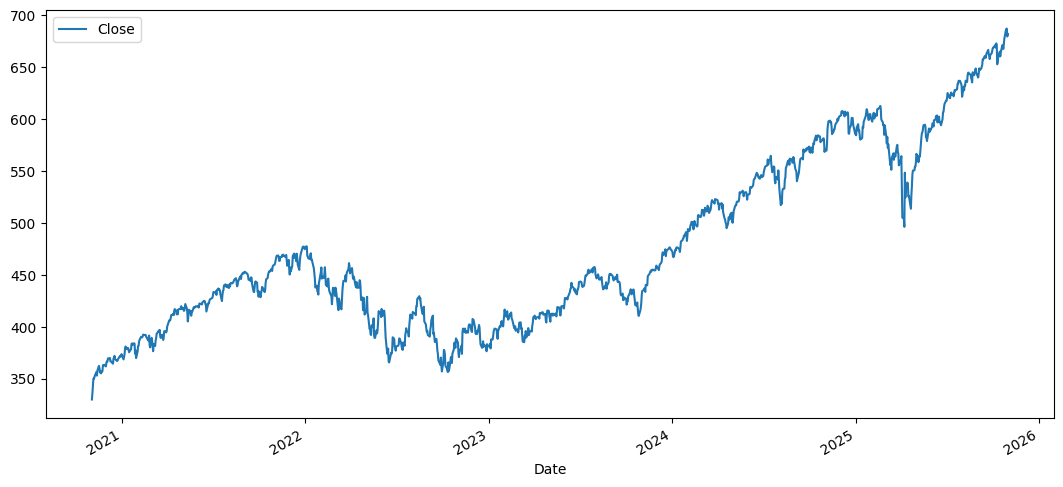

In [4]:
# plt.figure(figsize=(13, 6))
# plt.plot(spy_prices.index, spy_prices['Close'])
spy_prices.plot(kind='line', figsize=(13, 6))
plt.show()

In [5]:
df = spy_prices.copy()

df['avg_50day'] = spy_prices['Close'].rolling(50).mean()
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Close,avg_50day
Date,,
2020-11-02,330.20,NaN
2020-11-03,336.03,NaN
2020-11-04,343.54,NaN
2020-11-05,350.24,NaN
2020-11-06,350.16,NaN
...,...,...
2025-10-27,685.24,658.5806
2025-10-28,687.06,659.4558
2025-10-29,687.39,660.4074


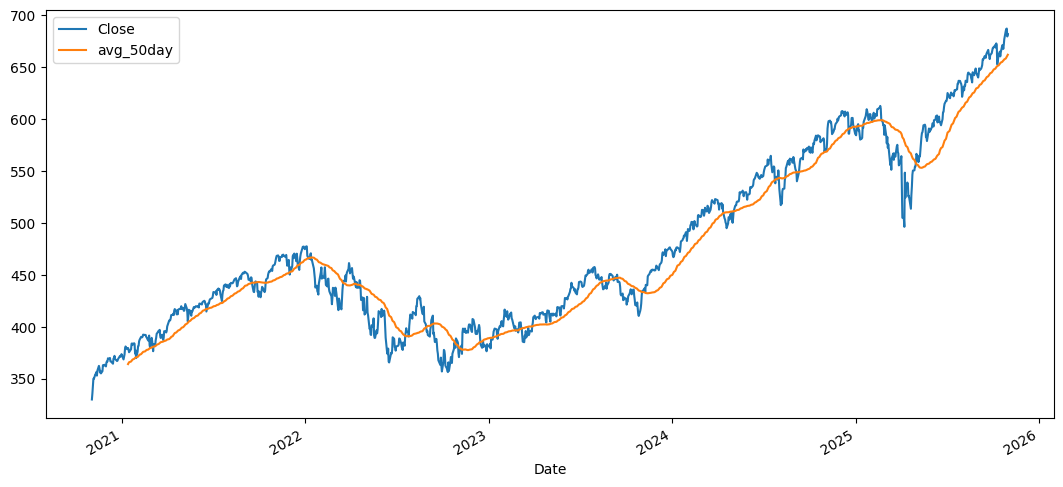

In [6]:
df.plot(kind='line', figsize=(13, 6))
plt.show()

In [7]:
df['avg_200day'] = spy_prices['Close'].rolling(200).mean()
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Close,avg_50day,avg_200day
Date,,,
2020-11-02,330.20,NaN,NaN
2020-11-03,336.03,NaN,NaN
2020-11-04,343.54,NaN,NaN
2020-11-05,350.24,NaN,NaN
2020-11-06,350.16,NaN,NaN
...,...,...,...
2025-10-27,685.24,658.5806,607.44455
2025-10-28,687.06,659.4558,607.97740
2025-10-29,687.39,660.4074,608.50740


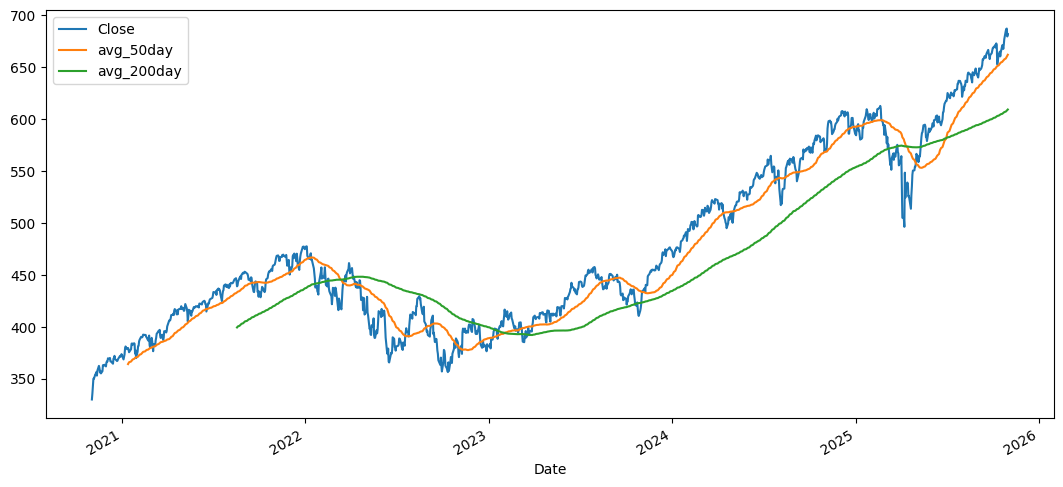

In [8]:
df.plot(kind='line', figsize=(13, 6))
plt.show()

In [9]:
df['gc'] = np.where(
    (df['avg_50day'].shift(1) < df['avg_200day'].shift(1)) &
    (df['avg_50day'] >= df['avg_200day']),
    1, 0)

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)


## What was the close price on the date of the most recent "golden cross"? (numbers only, no currency symbols)

In [10]:
df.loc[df['gc'] == 1, 'Close'].iat[-1]

617.65

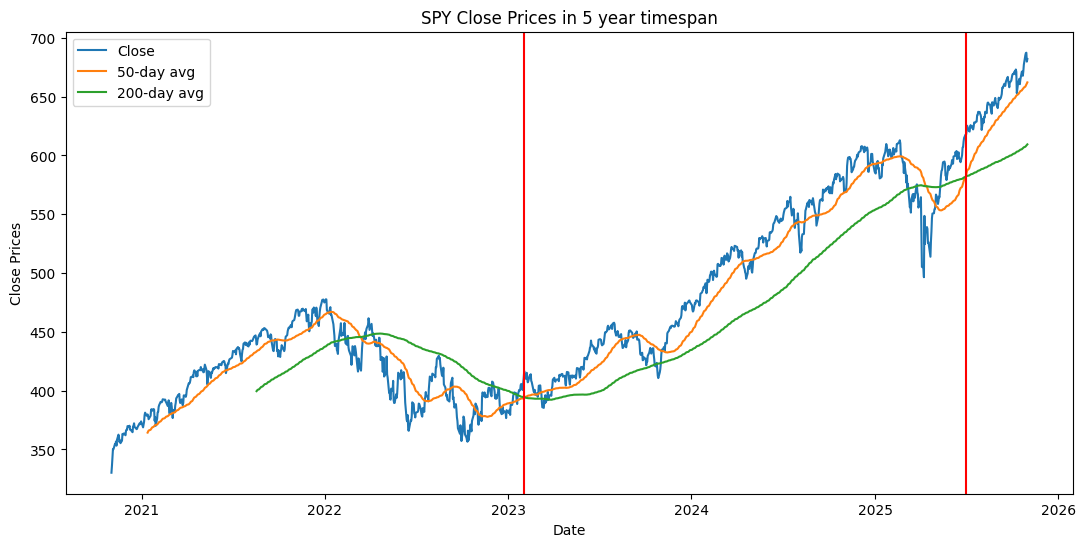

In [11]:
plt.figure(figsize=(13,6))
plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, df['avg_50day'], label='50-day avg')
plt.plot(df.index, df['avg_200day'], label='200-day avg')
for date in df[df['gc'] == 1].index:
    plt.axvline(date, color='r')
plt.title("SPY Close Prices in 5 year timespan")
plt.xlabel("Date")
plt.ylabel("Close Prices")
plt.legend()
plt.show()